<a href="https://colab.research.google.com/github/mikhaelabraham07/TUGAS2_MACHINE_LEARNING/blob/main/TUGAS2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.decomposition import PCA
from sklearn.utils import shuffle

from scipy.stats import mode

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("DataSpotify.csv", sep=';')
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0.0,0.611,0.389,99373.0,0.910,0,C#,0.3460,-1.828,Major,0.0525,166.969,04-Apr,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1.0,0.246,0.590,137373.0,0.737,0,F#,0.1510,-5.559,Minor,0.0868,174.003,04-Apr,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3.0,0.952,0.663,170267.0,0.131,0,C,0.1030,-13.879,Minor,0.0362,99.488,05-Apr,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0.0,0.703,0.240,152427.0,0.326,0,C#,0.0985,-12.178,Major,0.0395,171.758,04-Apr,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4.0,0.95,0.331,82625.0,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,04-Apr,0.390


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232723 non-null  object 
 3   track_id          232523 non-null  object 
 4   popularity        232523 non-null  float64
 5   acousticness      232523 non-null  object 
 6   danceability      232523 non-null  float64
 7   duration_ms       232523 non-null  float64
 8   energy            232523 non-null  float64
 9   instrumentalness  232523 non-null  object 
 10  key               232523 non-null  object 
 11  liveness          232523 non-null  float64
 12  loudness          232523 non-null  float64
 13  mode              232523 non-null  object 
 14  speechiness       232523 non-null  float64
 15  tempo             232523 non-null  float64
 16  time_signature    23

,popularity,danceability,duration_ms,energy,liveness,loudness,speechiness,tempo,valence
count,232523.000000,232523.000000,2.325230e+05,232523.000000,232523.000000,232523.000000,232523.000000,232523.000000,232523.000000
mean,41.135268,0.554417,2.350840e+05,0.571076,0.214933,-9.566649,0.120798,117.670817,0.454888
std,18.187301,0.185614,1.187243e+05,0.263423,0.198185,5.996772,0.185553,30.899835,0.260053
min,0.000000,0.056900,1.538700e+04,0.000020,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.435000,1.828625e+05,0.386000,0.097400,-11.767000,0.036700,92.961500,0.237000
50%,43.000000,0.571000,2.204160e+05,0.605000,0.128000,-7.759000,0.050100,115.785000,0.444000
75%,55.000000,0.692000,2.657200e+05,0.787000,0.264000,-5.500000,0.105000,139.064000,0.660000
max,100.000000,0.989000,5.552917e+06,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


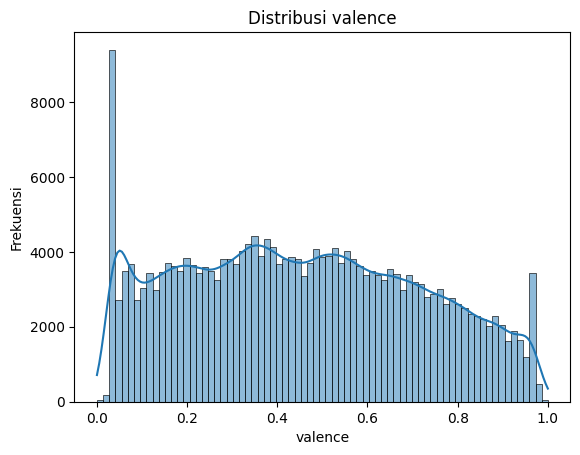

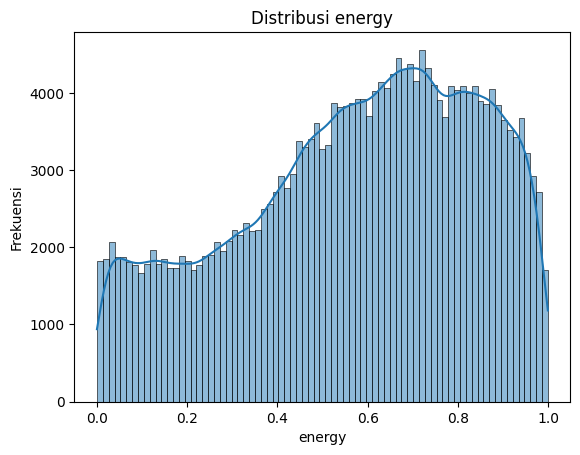

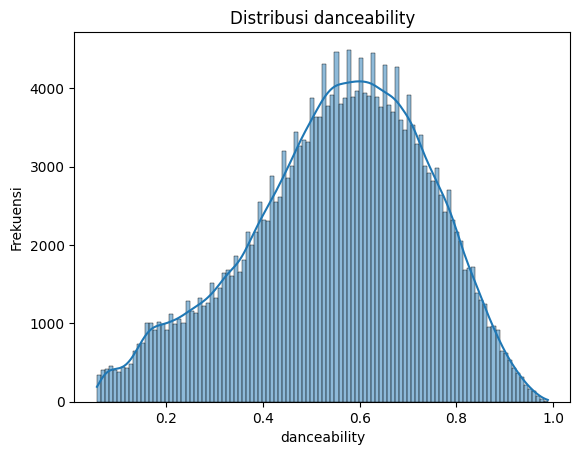

In [ ]:
for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

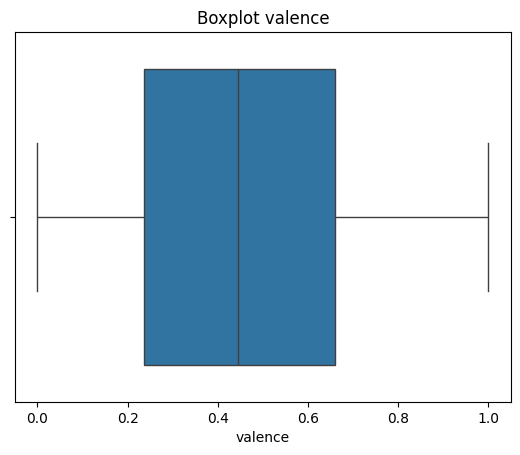

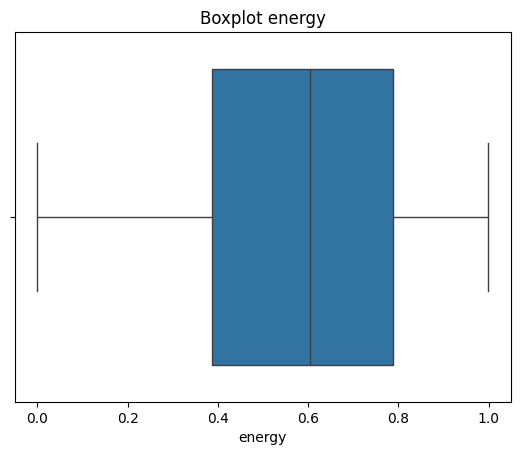

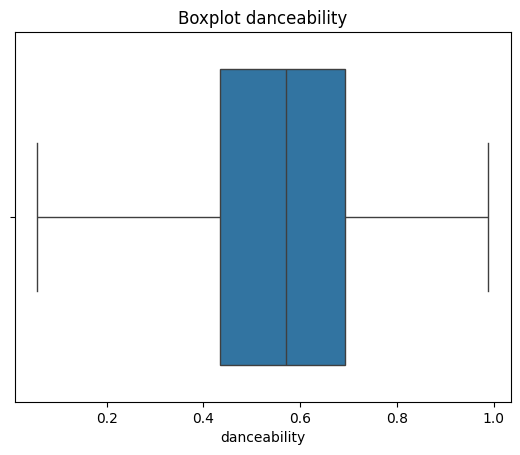

In [ ]:
for col in features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()

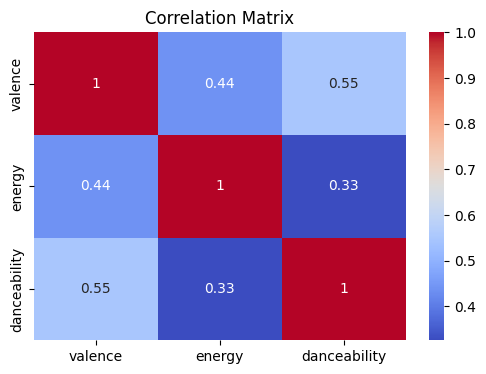

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

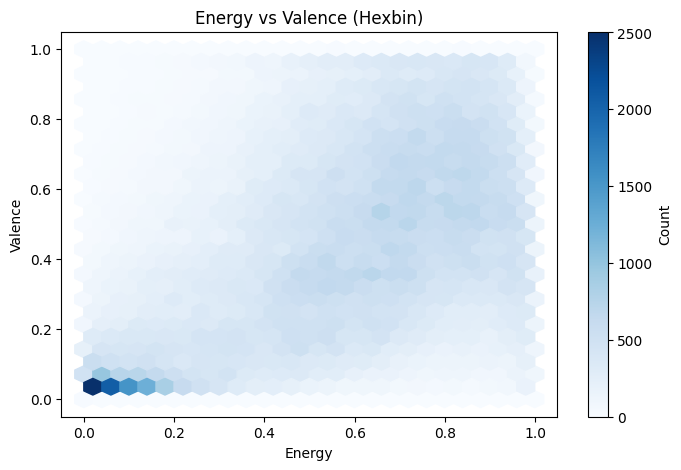

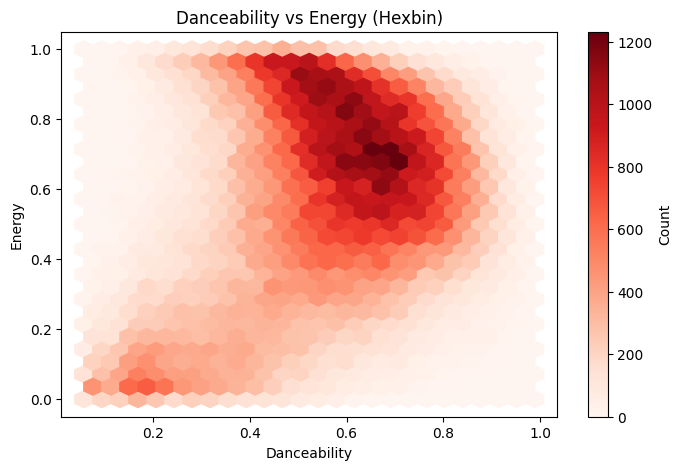

In [ ]:
plt.figure(figsize=(8,5))
plt.hexbin(df['energy'], df['valence'], gridsize=25, cmap='Blues')
plt.colorbar(label='Count')
plt.title("Energy vs Valence (Hexbin)")
plt.xlabel("Energy")
plt.ylabel("Valence")
plt.show()

plt.figure(figsize=(8,5))
plt.hexbin(df['danceability'], df['energy'], gridsize=25, cmap='Reds')
plt.colorbar(label='Count')
plt.title("Danceability vs Energy (Hexbin)")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.show()

In [ ]:
features = ['valence', 'energy', 'danceability']
df = df[features].dropna()

In [ ]:
def get_mood(row):
    if row['valence'] > 0.6 and row['energy'] > 0.6:
        return "Happy"
    elif row['valence'] < 0.4 and row['energy'] < 0.5:
        return "Sad"
    else:
        return "Calm"

df['mood'] = df.apply(get_mood, axis=1)

In [ ]:
le = LabelEncoder()
df['mood_label'] = le.fit_transform(df['mood'])

In [ ]:
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[features] < (Q1 - 1.5 * IQR)) | (df[features] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

# Re-create 'mood' and 'mood_label' columns if they are missing in df
# This ensures the column exists even if df was inadvertently reset.
if 'mood' not in df.columns:
    # Define get_mood function locally to ensure it's available
    def get_mood(row):
        if row['valence'] > 0.6 and row['energy'] > 0.6:
            return "Happy"
        elif row['valence'] < 0.4 and row['energy'] < 0.5:
            return "Sad"
        else:
            return "Calm"
    df['mood'] = df.apply(get_mood, axis=1)

if 'mood_label' not in df.columns:
    # Initialize LabelEncoder locally if not in global scope
    try:
        le
    except NameError:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
    df['mood_label'] = le.fit_transform(df['mood'])

y = df['mood_label'].values

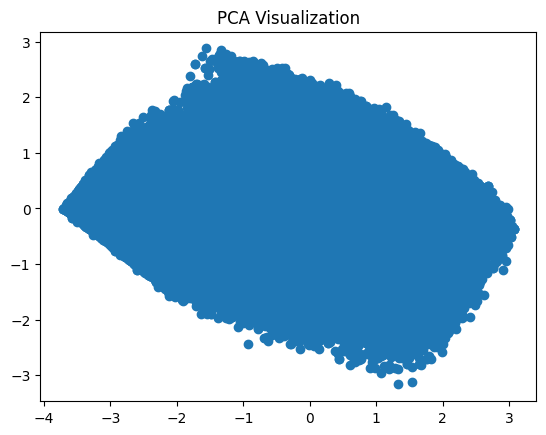

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization")
plt.show()

In [ ]:
X, y = shuffle(X, y, random_state=42)
X = X[:30000]
y = y[:30000]

In [ ]:
splits = {
    "70:30": train_test_split(X, y, test_size=0.3, random_state=42),
    "80:20": train_test_split(X, y, test_size=0.2, random_state=42),
    "90:10": train_test_split(X, y, test_size=0.1, random_state=42)
}

In [ ]:
def map_cluster(y_true, y_pred):
    mapped = np.zeros_like(y_pred)

    for i in np.unique(y_pred):
        mask = (y_pred == i)
        mapped[mask] = mode(y_true[mask], keepdims=True)[0]

    return mapped

In [ ]:
results = []

for split_name, (X_train, X_test, y_train, y_test) in splits.items():

    # ================= KMEANS =================
    best_score = -1
    for k in range(2, 6):
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X_train)

        score = silhouette_score(X_train[:1000], labels[:1000])

        if score > best_score:
            best_score = score
            best_kmeans = model

    pred = best_kmeans.fit_predict(X_test)
    mapped = map_cluster(y_test, pred)

    acc = accuracy_score(y_test, mapped)
    sil = silhouette_score(X_test[:1000], pred[:1000])
    db = davies_bouldin_score(X_test, pred)

    results.append(["KMeans", split_name, acc, sil, db])


    # ================= GMM =================
    best_score = -1
    for k in range(2, 6):
        model = GaussianMixture(n_components=k, random_state=42)
        labels = model.fit_predict(X_train)

        score = silhouette_score(X_train[:1000], labels[:1000])

        if score > best_score:
            best_score = score
            best_gmm = model

    pred = best_gmm.fit_predict(X_test)
    mapped = map_cluster(y_test, pred)

    acc = accuracy_score(y_test, mapped)
    sil = silhouette_score(X_test[:1000], pred[:1000])
    db = davies_bouldin_score(X_test, pred)

    results.append(["GMM", split_name, acc, sil, db])


    # ================= AGGLO =================
    best_score = -1
    for k in range(2, 6):
        model = AgglomerativeClustering(n_clusters=k)
        labels = model.fit_predict(X_train)

        score = silhouette_score(X_train[:1000], labels[:1000])

        if score > best_score:
            best_score = score
            best_k = k

    model = AgglomerativeClustering(n_clusters=best_k)
    pred = model.fit_predict(X_test)
    mapped = map_cluster(y_test, pred)

    acc = accuracy_score(y_test, mapped)
    sil = silhouette_score(X_test[:1000], pred[:1000])
    db = davies_bouldin_score(X_test, pred)

    results.append(["Agglomerative", split_name, acc, sil, db])

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Split", "Accuracy", "Silhouette", "DB Index"])
results_df

,Model,Split,Accuracy,Silhouette,DB Index
0,KMeans,70:30,0.671333,0.400414,1.021723
1,GMM,70:30,0.732444,0.409675,0.932008
2,Agglomerative,70:30,0.688444,0.408332,0.847891
3,KMeans,80:20,0.670000,0.399331,1.028678
4,GMM,80:20,0.737333,0.407441,0.950474
5,Agglomerative,80:20,0.560000,0.276290,1.256844
6,KMeans,90:10,0.677333,0.403674,1.017587
7,GMM,90:10,0.726000,0.408902,0.959212
8,Agglomerative,90:10,0.701667,0.398234,0.963586


In [ ]:
results_df.sort_values(by="Silhouette", ascending=False)

,Model,Split,Accuracy,Silhouette,DB Index
1,GMM,70:30,0.732444,0.409675,0.932008
7,GMM,90:10,0.726000,0.408902,0.959212
2,Agglomerative,70:30,0.688444,0.408332,0.847891
4,GMM,80:20,0.737333,0.407441,0.950474
6,KMeans,90:10,0.677333,0.403674,1.017587
0,KMeans,70:30,0.671333,0.400414,1.021723
3,KMeans,80:20,0.670000,0.399331,1.028678
8,Agglomerative,90:10,0.701667,0.398234,0.963586
5,Agglomerative,80:20,0.560000,0.276290,1.256844


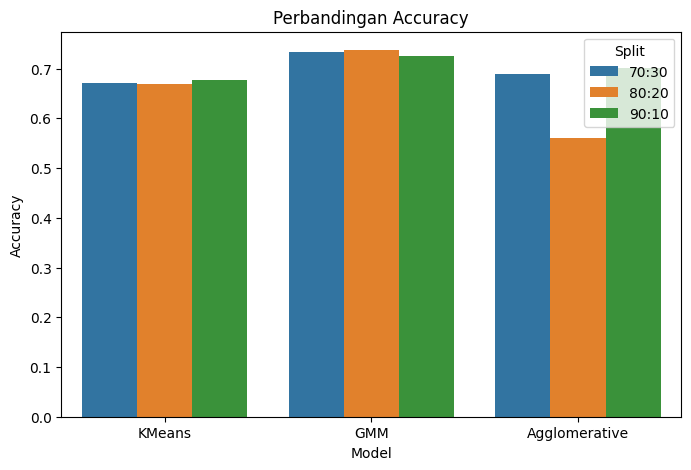

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="Accuracy", hue="Split")
plt.title("Perbandingan Accuracy")
plt.show()

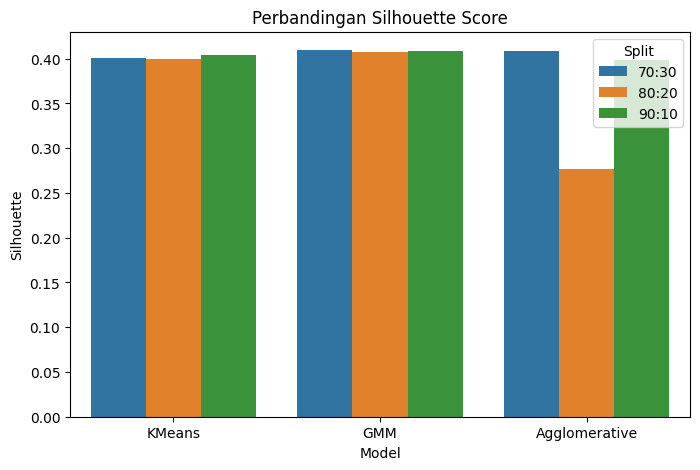

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="Silhouette", hue="Split")
plt.title("Perbandingan Silhouette Score")
plt.show()

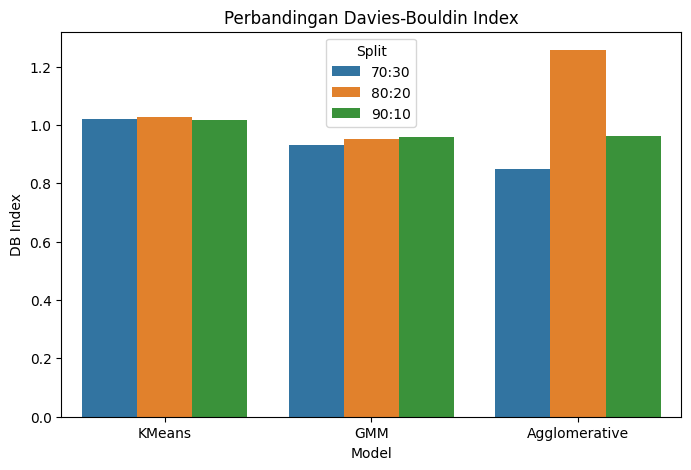

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="DB Index", hue="Split")
plt.title("Perbandingan Davies-Bouldin Index")
plt.show()

In [ ]:
best_model = results_df.sort_values(by="Silhouette", ascending=False).iloc[0]
print("Model Terbaik:")
print(best_model)

Model Terbaik:
Model              GMM
Split            70:30
Accuracy      0.732444
Silhouette    0.409675
DB Index      0.932008
Name: 1, dtype: object


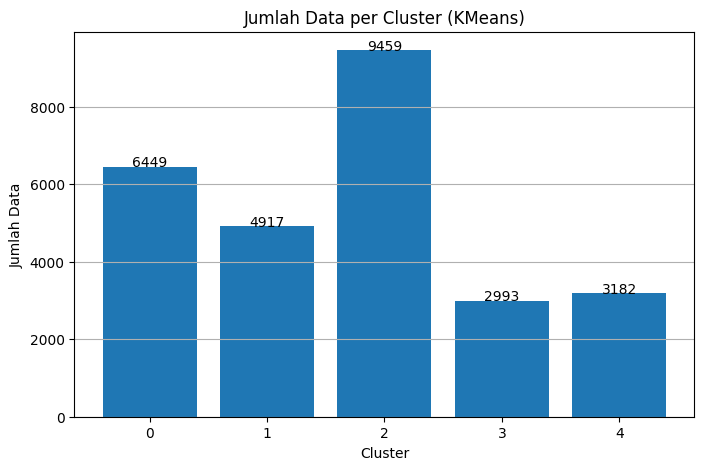

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Hitung jumlah data di tiap cluster
unique, counts = np.unique(labels, return_counts=True)

# Plot diagram batang
plt.figure(figsize=(8, 5))
plt.bar(unique, counts)

plt.title("Jumlah Data per Cluster (KMeans)")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Data")
plt.xticks(unique)

# Tambahkan angka di atas batang
for i, v in enumerate(counts):
    plt.text(unique[i], v + 1, str(v), ha='center')

plt.grid(axis='y')
plt.show()

In [ ]:
!pip install spotipy

In [ ]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
sp_oauth = SpotifyOAuth(
    client_id="c008c91b6bd24da8a325f13f1406d928",
    client_secret="8b13e611a3cf42ad92650adef614a568",
    redirect_uri="http://127.0.0.1:8888/callback",
    scope=None
)

auth_url = sp_oauth.get_authorize_url()
print("Klik link ini, login Spotify, lalu copy URL redirect:\n")
print(auth_url)

Klik link ini, login Spotify, lalu copy URL redirect:

https://accounts.spotify.com/authorize?client_id=c008c91b6bd24da8a325f13f1406d928&response_type=code&redirect_uri=http%3A%2F%2F127.0.0.1%3A8888%2Fcallback


In [ ]:
response_url = input("Paste URL redirect di sini: ")

code = sp_oauth.parse_response_code(response_url)
token_info = sp_oauth.get_access_token(code)

sp = spotipy.Spotify(auth=token_info['access_token'])

print("Login berhasil!")

Paste URL redirect di sini: http://127.0.0.1:8888/callback?code=AQAp0c69Kin4gcUwDxTaW97wta9TsA94WuO6hTHX29CHZ6We0UXvc2-d3k1ZOD1_jiryVEunojpLVm911S5WclUnNscZscucxC85XR4L4MqLaXEwwmRDaJi1JSwMa3CvNp707Tplhiu-R7a5nICKSd4hUfdEzf-sR_LIUVZx4rsyaQ
Login berhasil!


In [ ]:
# ambil data awal untuk training model
results = sp.search(q="pop", type="track", limit=50)
tracks = results['tracks']['items']

track_ids = [t['id'] for t in tracks]

features = sp.audio_features(track_ids)

df_train = pd.DataFrame(features)

# pilih fitur
X = df_train[['valence', 'energy', 'danceability', 'tempo']]

# normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

print("Model berhasil dibuat!")

ERROR:spotipy.client:HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'pop', 'limit': 50, 'offset': 0, 'type': 'track', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.


SpotifyException: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=pop&limit=50&offset=0&type=track:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None

In [ ]:
mood = input("Masukkan mood (galau/happy/chill/romantic): ").lower()

Masukkan mood (galau/happy/chill/romantic): galau


In [ ]:
def rekomendasi_mood(mood):
    mood_map = {
        "sad": "sad",
        "galau": "sad",
        "happy": "happy",
        "senang": "happy",
        "chill": "chill",
        "tenang": "chill",
        "romantic": "love",
        "marah": "angry"
    }

    query = mood_map.get(mood, "pop")

    results = sp.search(q=query, type="track", limit=20)
    tracks = results['tracks']['items']

    track_ids = [t['id'] for t in tracks]
    names = [t['name'] for t in tracks]
    artists = [t['artists'][0]['name'] for t in tracks]

    features = sp.audio_features(track_ids)

    df = pd.DataFrame(features)
    df['track_name'] = names
    df['artist'] = artists

    X = df[['valence', 'energy', 'danceability', 'tempo']]
    X_scaled = scaler.transform(X)

    df['cluster'] = kmeans.predict(X_scaled)

    # logika pemilihan cluster
    if mood in ["sad", "galau"]:
        target_cluster = df.groupby('cluster')['valence'].mean().idxmin()
    elif mood in ["happy", "senang"]:
        target_cluster = df.groupby('cluster')['valence'].mean().idxmax()
    else:
        target_cluster = df['cluster'].mode()[0]

    hasil = df[df['cluster'] == target_cluster]

    return hasil[['track_name', 'artist']]

In [ ]:
hasil = rekomendasi_mood(mood)

print("\n🎧 Rekomendasi Lagu:\n")
print(hasil.head(10))

ERROR:spotipy.client:HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'sad', 'limit': 20, 'offset': 0, 'type': 'track', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.


SpotifyException: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=sad&limit=20&offset=0&type=track:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None